In [1]:
import pickle
import polars as pl
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
#np.set_printoptions(suppress=True, precision=3)
#pd.options.display.float_format = '{:.0f}'.format
import matplotlib.pyplot as plt

## ETS

In [2]:
ets = pd.read_parquet("results/ETS-batch.parquet")
ets.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.889725,32.341223,-1.230709,0.500413,ETS
1,125960550,1,5.257994,35.007336,-1.572577,0.546295,ETS
2,125960550,2,5.786613,46.518887,-2.265364,0.688294,ETS
3,125960550,3,5.420447,46.464988,-2.073230,0.656523,ETS
4,125960550,4,5.404102,48.147106,-2.655442,0.662021,ETS


In [3]:
ets.shape

(380, 7)

In [4]:
ets["mae"].mean(), ets["mape"].mean(), ets["mse"].mean(), ets["r2"].mean()

(140.70901012028548,
 0.6852637942018918,
 105877.9870150889,
 0.06128230140722971)

In [5]:
ets["mae"].std(), ets["mape"].std(), ets["mse"].std(), ets["r2"].std()

(209.19224292963048, 0.32099177946329016, 263675.3814793, 0.7844798539213508)

In [6]:
with open('results/ETS-targets.pkl', 'rb') as f:
    ets_targets = pickle.load(f)

In [7]:
ets_targets.keys()

dict_keys([53, 365, 382, 666, 701, 1326, 1404, 1569, 1916, 2617])

In [8]:
len(ets_targets[53])

38

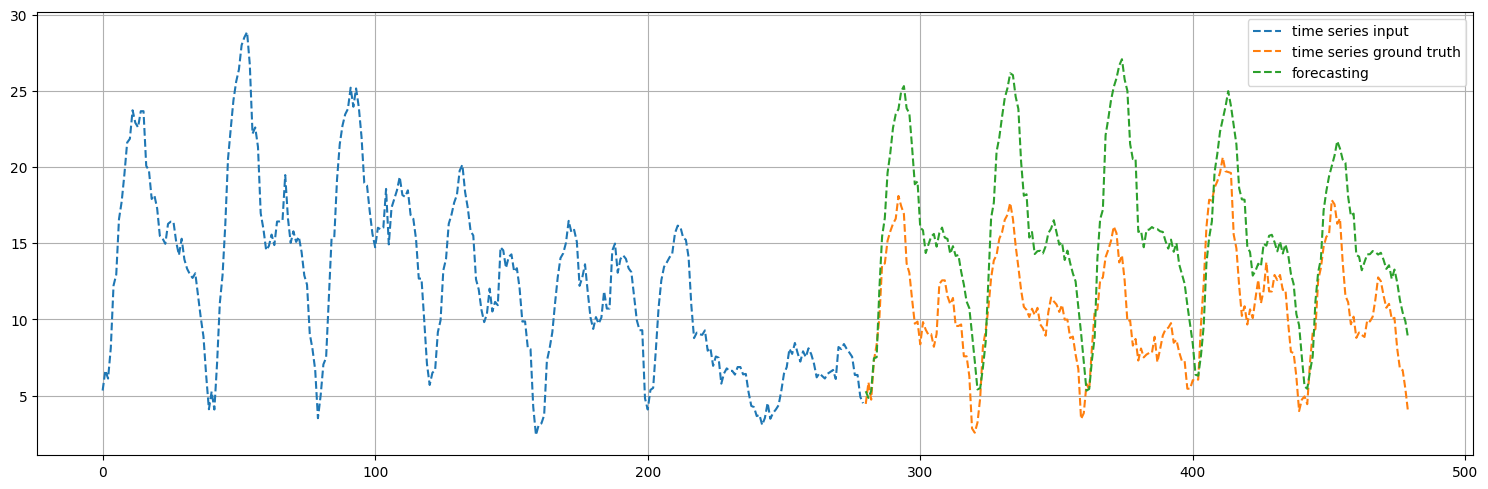

In [9]:
batch_idx = 0
node_ts = ets_targets[53]
forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], '--', label="time series input")
plt.plot(forecast_index, node_ts[batch_idx]["true"], '--', label="time series ground truth")
plt.plot(forecast_index, node_ts[batch_idx]["pred"], '--', label="forecasting")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [10]:
len(node_ts[batch_idx]["input"]), node_ts[batch_idx]["true"].shape

(280, (200,))

## Prophet

In [11]:
proph = pd.read_parquet("results/prophet-batch.parquet")
proph.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,6.184129,54.194856,-2.738046,0.708893,prophet
1,125960550,1,6.234772,54.744795,-3.023020,0.712944,prophet
2,125960550,2,6.856584,64.557575,-3.531579,0.901209,prophet
3,125960550,3,6.696947,64.544619,-3.269030,0.822222,prophet
4,125960550,4,6.220929,54.074972,-3.105500,0.782420,prophet


In [12]:
proph.shape

(380, 7)

In [13]:
proph["mae"].mean(), proph["mape"].mean(), proph["mse"].mean(), proph["r2"].mean()

(244.18961070042806,
 1.0469632408121237,
 238431.9120207524,
 -1.4164776470875238)

In [14]:
proph["mae"].std(), proph["mape"].std(), proph["mse"].std(), proph["r2"].std()

(325.0962846116718,
 0.35396329905428514,
 517530.10064032226,
 0.6506819255942414)

In [15]:
with open('results/prophet-targets.pkl', 'rb') as f:
    ph_targets = pickle.load(f)

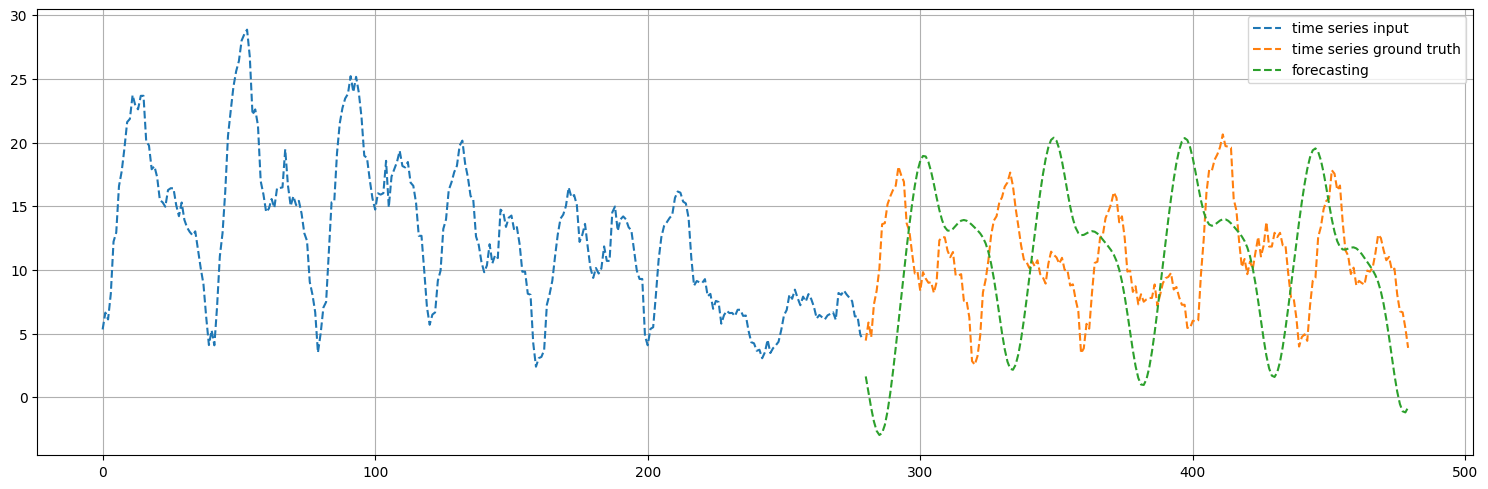

In [16]:
batch_idx = 0
node_ts = ph_targets[53]
forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])

plt.figure(figsize=(15,5))
plt.plot(node_ts[batch_idx]["input"], '--', label="time series input")
plt.plot(forecast_index, node_ts[batch_idx]["true"], '--', label="time series ground truth")
plt.plot(forecast_index, node_ts[batch_idx]["pred"], '--', label="forecasting")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## SARIMA

In [17]:
sarima = pd.read_parquet("results/sarima-batch.parquet")
sarima

,node,batch,mae,mse,r2,mape
0,125960550,0,10.347068,122.236784,-7.431182,0.944086
1,125960550,1,10.996744,135.814391,-8.980565,1.050288
2,125960550,2,10.407377,124.126579,-7.712988,1.046834
3,125960550,3,9.848582,110.801220,-6.328477,0.940071
4,125960550,4,10.188016,117.117835,-7.891864,0.988669
...,...,...,...,...,...,...
375,47568123,33,122.099164,18529.506844,-4.207897,1.004404
376,47568123,34,134.864332,22125.282199,-4.781296,0.989111
377,47568123,35,154.844988,26676.694033,-9.395470,0.996625
378,47568123,36,149.790391,25897.941344,-7.938702,1.052741


In [18]:
sarima["mae"].mean(), sarima["mape"].mean(), sarima["mse"].mean(), sarima["r2"].mean()

(295.1542481560667, 0.9060360463396424, 352047.63172737433, -3.052604388194399)

In [19]:
sarima["mae"].std(), sarima["mape"].std(), sarima["mse"].std(), sarima["r2"].std()

(431.714215640482, 0.17389742525396437, 909150.6959816306, 2.2820311917679508)

In [20]:
with open('results/SARIMA-FIT-targets.pkl', 'rb') as f:
    sarima_targets = pickle.load(f)

## MLP

In [21]:
mlp = pd.read_parquet("results/MLP-batch-batch.parquet")
mlp.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,9.315366,110.852805,-6.645981,1.010148,MLP-batch
1,125960550,1,7.719656,75.548898,-4.551847,0.842993,MLP-batch
2,125960550,2,17.330191,328.927969,-22.088893,2.197176,MLP-batch
3,125960550,3,2.223090,8.417102,0.443286,0.229237,MLP-batch
4,125960550,4,2.369555,9.244600,0.298128,0.241542,MLP-batch


In [22]:
print(f"{mlp['mae'].mean():,.0f}")

304


In [23]:
print(f"{mlp['mae'].mean():.0f}")

304


In [24]:
valores = (mlp["mae"].mean(), mlp["mape"].mean(), mlp["mse"].mean(), mlp["r2"].mean())
valores

(303.65930415434894,
 1.8105845381446306,
 456352.40874671063,
 -4.343027334424497)

In [25]:
valores = (mlp["mae"].std(), mlp["mape"].std(), mlp["mse"].std(), mlp["r2"].std())
valores

(503.20417899004207, 1.6234938420567795, 1934389.7874853734, 8.231018027594455)

In [26]:
with open('results/MLP-batch-targets.pkl', 'rb') as f:
    mlp_targets = pickle.load(f)

## LSTM

In [27]:
lstm = pd.read_parquet("results/LSTM-batch-batch.parquet")
lstm.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,5.551886,42.974556,-1.964135,0.466394,LSTM-batch
1,125960550,1,5.073580,36.829794,-1.706504,0.439574,LSTM-batch
2,125960550,2,4.756241,33.869724,-1.377464,0.429795,LSTM-batch
3,125960550,3,5.280090,40.502376,-1.678858,0.455207,LSTM-batch
4,125960550,4,4.531611,30.006301,-1.278149,0.412113,LSTM-batch


In [28]:
lstm["mae"].mean(), lstm["mape"].mean(), lstm["mse"].mean(), lstm["r2"].mean()

(373.99773447821957,
 0.8516580902844462,
 512354.36422683124,
 -3.1101234242066855)

In [29]:
lstm["mae"].std(), lstm["mape"].std(), lstm["mse"].std(), lstm["r2"].std()

(527.0201176006257,
 0.17160045529427173,
 1110621.5412533968,
 2.1166037204331603)

In [30]:
with open('results/LSTM-batch-targets.pkl', 'rb') as f:
    lstm_targets = pickle.load(f)

## GRU

In [31]:
gru = pd.read_parquet("results/GRU-batch-batch.parquet")
gru.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.292277,28.520813,-0.967200,0.369582,GRU-batch
1,125960550,1,3.950637,24.746542,-0.818544,0.348510,GRU-batch
2,125960550,2,3.684526,22.215682,-0.559416,0.356280,GRU-batch
3,125960550,3,4.143482,26.449974,-0.749421,0.381271,GRU-batch
4,125960550,4,3.993938,23.183800,-0.760169,0.381915,GRU-batch


In [32]:
gru["mae"].mean(), gru["mape"].mean(), gru["mse"].mean(), gru["r2"].mean()

(373.9064571400442, 0.8420049039984655, 512341.0926630293, -3.0441363395002603)

In [33]:
gru["mae"].std(), gru["mape"].std(), gru["mse"].std(), gru["r2"].std()

(526.9581417126253, 0.18857244362426004, 1110451.296256676, 2.1787168280092732)

In [34]:
with open('results/GRU-batch-targets.pkl', 'rb') as f:
    gru_targets = pickle.load(f)

## Chronos Base

In [35]:
cbase = pd.read_parquet("results/cronos-chronos-t5-base-batch.parquet")
cbase.head()

,node,batch,mae,mse,r2,mape,model
0,125960550,0,4.893786,34.260635,-1.363099,0.456280,chronos-t5-base
1,125960550,1,8.535946,87.492577,-5.429549,0.811169,chronos-t5-base
2,125960550,2,3.940104,26.630894,-0.869339,0.428015,chronos-t5-base
3,125960550,3,6.390084,56.959179,-2.767323,0.861574,chronos-t5-base
4,125960550,4,3.251440,20.305840,-0.541668,0.419599,chronos-t5-base


In [36]:
cbase["mae"].mean(), cbase["mape"].mean(),cbase["mse"].mean(), cbase["r2"].mean()

(227.84943405891718,
 0.8689351560253846,
 254372.18724111255,
 -1.2965708026760503)

In [37]:
cbase["mae"].std(), cbase["mape"].std(), cbase["mse"].std(), cbase["r2"].std()

(366.53051289066235, 0.43977562833756156, 784921.7451010472, 2.893850680424422)

In [38]:
with open('results/chronos-t5-base-targets.pkl', 'rb') as f:
    chr_targets = pickle.load(f)

## Times fs 200

In [39]:
## TimesFS 200
with open('results/timesfm-1.0-200m-pytorch-targets-batch.pkl', 'rb') as f:
    ts200_targets = pickle.load(f)

In [40]:
with open('results/timesfm-2.0-500m-pytorch-targets-batch.pkl', 'rb') as f:
    ts500_targets = pickle.load(f)

## TEMPO

In [66]:
with open('results/tempo-short-targets.pkl', 'rb') as f:
    tempo_targets = pickle.load(f)

In [75]:
len(tempo_targets)

38

In [80]:
tempo_targets[0][0].keys()

dict_keys(['input', 'true', 'pred'])

## PLOT all

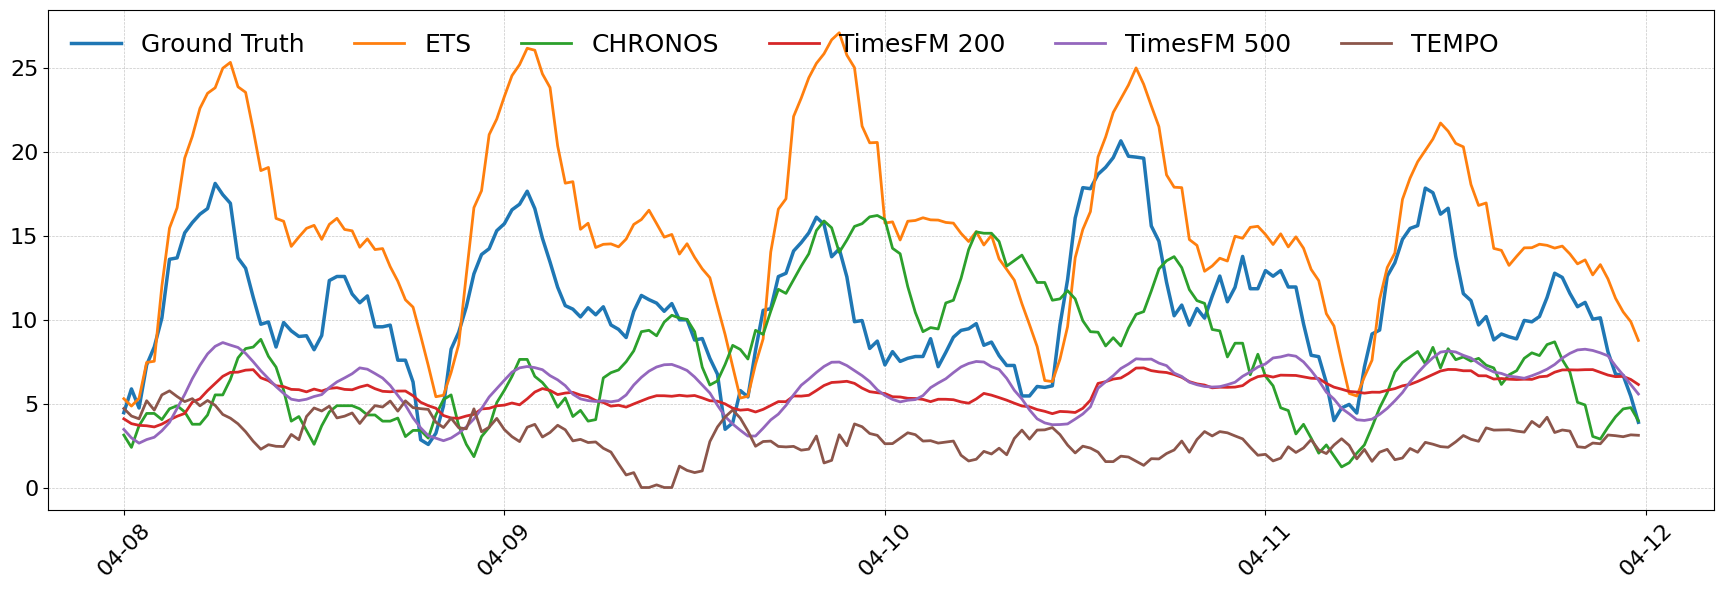

In [84]:
### Plot All
batch_idx = 0

node_idx = 53
node_ts_ph = ph_targets[node_idx]
node_ts_ets = ets_targets[node_idx]
node_ts_sarima = sarima_targets[node_idx]

node_ts_mlp = mlp_targets[node_idx]
node_ts_lstm = lstm_targets[node_idx]
node_ts_gru = gru_targets[node_idx]
node_ts_chronos = chr_targets[node_idx]
node_ts_200 = ts200_targets[node_idx]
node_ts_500 = ts500_targets[node_idx]
node_tempo =  tempo_targets[0]



forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])


plt.figure(figsize=(18,6))
# Traçar as curvas com espessura apropriada
plt.plot(forecast_index, node_ts[batch_idx]["true"], linewidth=2.5, label="Ground Truth")
plt.plot(forecast_index, node_ts_ets[batch_idx]["pred"], linewidth=2.0, label="ETS")
# plt.plot(forecast_index, node_ts_ph[batch_idx]["pred"], linewidth=2.0, label="Prophet")
# plt.plot(forecast_index, node_ts_sarima[batch_idx]["pred"], linewidth=2.0, label="SARIMA")
# plt.plot(forecast_index, node_ts_mlp[batch_idx]["pred"], linewidth=2.0, label="MLP")
# plt.plot(forecast_index, node_ts_lstm[batch_idx]["pred"], linewidth=2.0, label="LSTM")
# plt.plot(forecast_index, node_ts_gru[batch_idx]["pred"], linewidth=2.0, label="GRU")
plt.plot(forecast_index, node_ts_chronos[batch_idx]["pred"], linewidth=2.0, label="CHRONOS")
plt.plot(forecast_index, node_ts_200[batch_idx]["pred"], linewidth=2.0, label="TimesFM 200")
plt.plot(forecast_index, node_ts_500[batch_idx]["pred"], linewidth=2.0, label="TimesFM 500")
plt.plot(forecast_index, node_tempo[batch_idx]["pred"], linewidth=2.0, label="TEMPO")

datas = ['04-08', '04-09', '04-10', '04-11','04-12']
valores = np.linspace(280, 480, num=len(datas), dtype=int)
# Eixos e títulos
plt.xlabel("", fontsize=14)
plt.ylabel("", fontsize=14)
#plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks=valores, labels=datas, fontsize=16, rotation=45)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=18, loc='upper left', frameon=False, ncol=6)

# Layout compacto
plt.tight_layout()
plt.savefig("forecast_batch.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [64]:
forecast_index

range(280, 480)

In [46]:

print(valores.tolist())

[280, 330, 380, 430, 480]


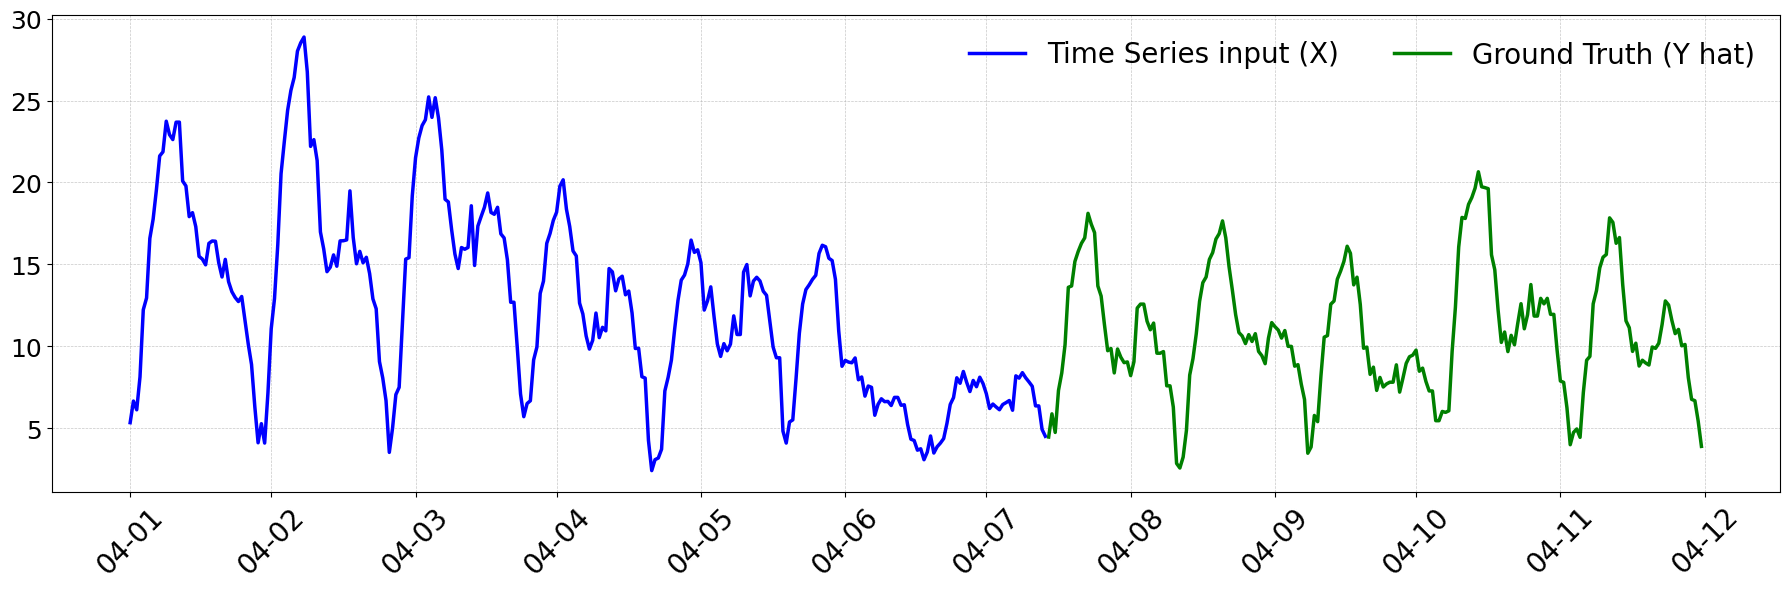

In [59]:
### Plot All
batch_idx = 0

node_idx = 53
# node_ts_ph = ph_targets[node_idx]
# node_ts_ets = ets_targets[node_idx]
# node_ts_sarima = sarima_targets[node_idx]

# node_ts_mlp = mlp_targets[node_idx]
# node_ts_lstm = lstm_targets[node_idx]
# node_ts_gru = gru_targets[node_idx]
# node_ts_chronos = chr_targets[node_idx]
# node_ts_200 = ts200_targets[node_idx]



forecast_index = range(len(node_ts[batch_idx]["input"]), 
                       len(node_ts[batch_idx]["input"]) + node_ts[batch_idx]["true"].shape[0])


plt.figure(figsize=(18,6))
# Traçar as curvas com espessura apropriada
plt.plot(node_ts[batch_idx]["input"], 'blue', linewidth=2.5, label="Time Series input (X)")
plt.plot(forecast_index, node_ts[batch_idx]["true"], linewidth=2.5, color='green', label="Ground Truth (Y hat)")

datas = ['04-01', '04-02', '04-03', '04-04','04-05','04-06','04-07','04-08', '04-09', '04-10', '04-11','04-12']
valores = np.linspace(0, 480, num=len(datas), dtype=int)

# Eixos e títulos
plt.xlabel("", fontsize=14)
plt.ylabel("", fontsize=14)
# plt.xticks(fontsize=16)
plt.xticks(ticks=valores, labels=datas, fontsize=20, rotation=45)
plt.yticks(fontsize=18)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
#plt.legend(fontsize=18, loc='upper left', frameon=False, ncol=3)
plt.legend(fontsize=20, loc='upper right', frameon=False, ncol=3)

# Layout compacto
plt.tight_layout()
plt.savefig(f"forecast_batch_53_x_y.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [53]:
forecast_index

range(280, 480)